In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Insight-Financial-Transaction-2024H1.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4777635 entries, 0 to 4777634
Data columns (total 27 columns):
 #   Column                                     Dtype  
---  ------                                     -----  
 0   ACCOUNT_ID                                 str    
 1   CARD_ID                                    str    
 2   TRANSACTION_ID                             str    
 3   GROSS_TRANSACTION_AMOUNT                   float64
 4   TRANSACTION_DATE                           str    
 5   TRANSACTION_TYPE                           str    
 6   TRANSACTION_STATE                          str    
 7   TRANSACTION_CITY                           str    
 8   MERCHANT_STATE                             str    
 9   MERCHANT_CITY                              str    
 10  MERCHANT_CATEGORY_LEVEL_1                  str    
 11  MERCHANT_CATEGORY_LEVEL_2                  str    
 12  MERCHANT_CATEGORY_LEVEL_3                  str    
 13  TRANSACTION_DESCRIPTION                    str    
 1

In [4]:
df.isnull().sum()

ACCOUNT_ID                                    132703
CARD_ID                                            0
TRANSACTION_ID                                     0
GROSS_TRANSACTION_AMOUNT                           0
TRANSACTION_DATE                                   0
TRANSACTION_TYPE                                   1
TRANSACTION_STATE                             121664
TRANSACTION_CITY                              143825
MERCHANT_STATE                                583358
MERCHANT_CITY                                 702539
MERCHANT_CATEGORY_LEVEL_1                    1293772
MERCHANT_CATEGORY_LEVEL_2                    1293772
MERCHANT_CATEGORY_LEVEL_3                    1293982
TRANSACTION_DESCRIPTION                         5463
CARD_TYPE                                          0
CARD_HOLDER_STATE                              19430
CARD_HOLDER_CITY                               19430
CARD_HOLDER_GENERATION                         57808
CARD_HOLDER_TOTAL_TRANSACTION_COUNT           

In [5]:
# 1. 채워넣을 대상 컬럼 설정
fill_cols = ['CARD_HOLDER_STATE', 'CARD_HOLDER_CITY']

print("거주지 결측치 복구 시작 (고속 매핑 방식)...")

for col in fill_cols:
    # 2. 각 고객(ACCOUNT_ID)별로 해당 컬럼의 최빈값(가장 많이 등장한 값) 하나를 추출합니다.
    # dropna=True로 설정하여 결측치는 제외하고 실제 값이 있는 것들 중에서만 뽑습니다.
    customer_home_map = df.dropna(subset=[col]).groupby('ACCOUNT_ID')[col].agg(lambda x: x.mode().iat[0])
    
    # 3. 원본 데이터에서 해당 컬럼이 비어있는(isnull) 행만 골라내어 
    # 위에서 만든 '고객별 거주지 사전'을 이용해 값을 채워넣습니다.
    df[col] = df[col].fillna(df['ACCOUNT_ID'].map(customer_home_map))

print("복구가 완료되었습니다!")

거주지 결측치 복구 시작 (고속 매핑 방식)...
복구가 완료되었습니다!


<Figure size 1400x800 with 0 Axes>

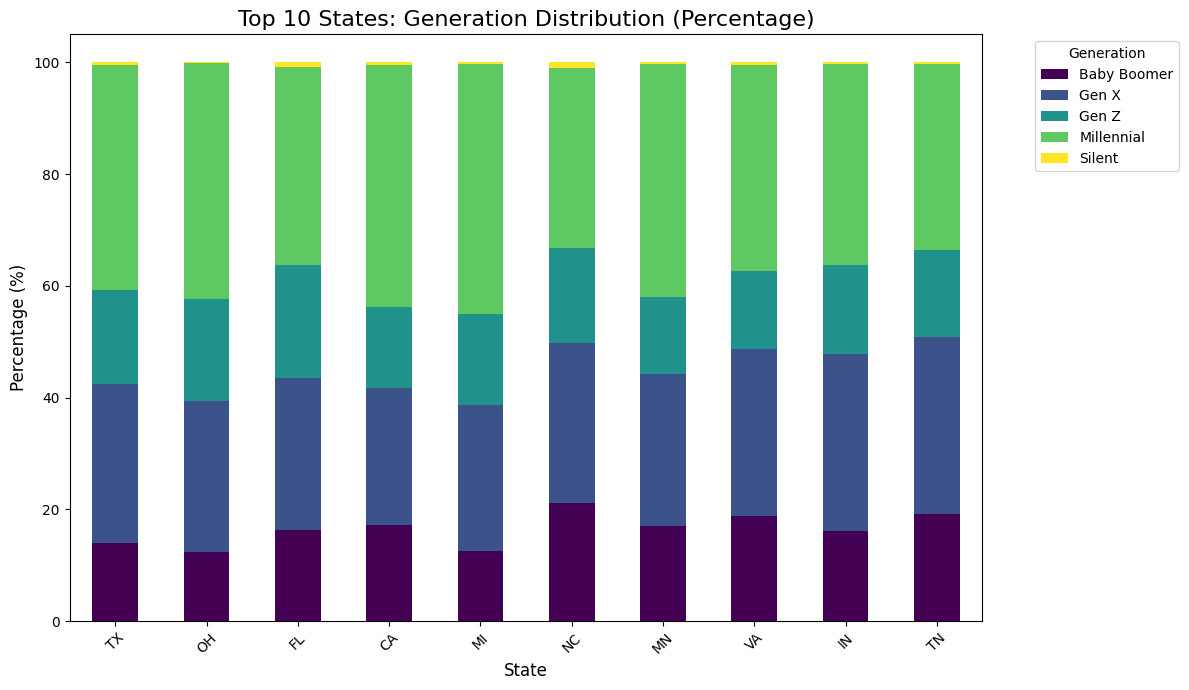

--- 주별 세대 인구 수 요약 (상위 5개 주) ---
CARD_HOLDER_GENERATION  Baby Boomer  Gen X  Gen Z  Millennial  Silent
CARD_HOLDER_STATE                                                    
TX                            43762  88659  52393      125946    1312
OH                            38544  84222  56520      131247     635
FL                            43639  72708  54495       94736    2330
CA                            39114  56144  33005       99086    1216
MI                            25617  53998  33548       92095     501


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 유니크 고객(ACCOUNT_ID) 기준 데이터 추출
# 한 고객이 여러 번 결제했으므로, 인구 분포를 보려면 중복을 제거해야 합니다.
user_profile = df.drop_duplicates(subset=['ACCOUNT_ID'])[['CARD_HOLDER_STATE', 'CARD_HOLDER_GENERATION']]

# 2. 지역(State) 및 세대(Generation)별 고객 수 집계
dist_df = user_profile.groupby(['CARD_HOLDER_STATE', 'CARD_HOLDER_GENERATION']).size().unstack(fill_value=0)

# 3. 비중(%)으로 변환 (각 주 내에서 세대별 비율)
dist_pct = dist_df.div(dist_df.sum(axis=1), axis=0) * 100

# --- 시각화 ---

# 고객 수가 가장 많은 상위 10개 주 추출 (전체 주를 다 그리면 너무 복잡함)
top_10_states = user_profile['CARD_HOLDER_STATE'].value_counts().nlargest(10).index
dist_pct_top10 = dist_pct.loc[top_10_states]

plt.figure(figsize=(14, 8))
dist_pct_top10.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 7))

plt.title('Top 10 States: Generation Distribution (Percentage)', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Generation', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# 4. 수치 요약표 출력
print("--- 주별 세대 인구 수 요약 (상위 5개 주) ---")
print(dist_df.loc[top_10_states[:5]])

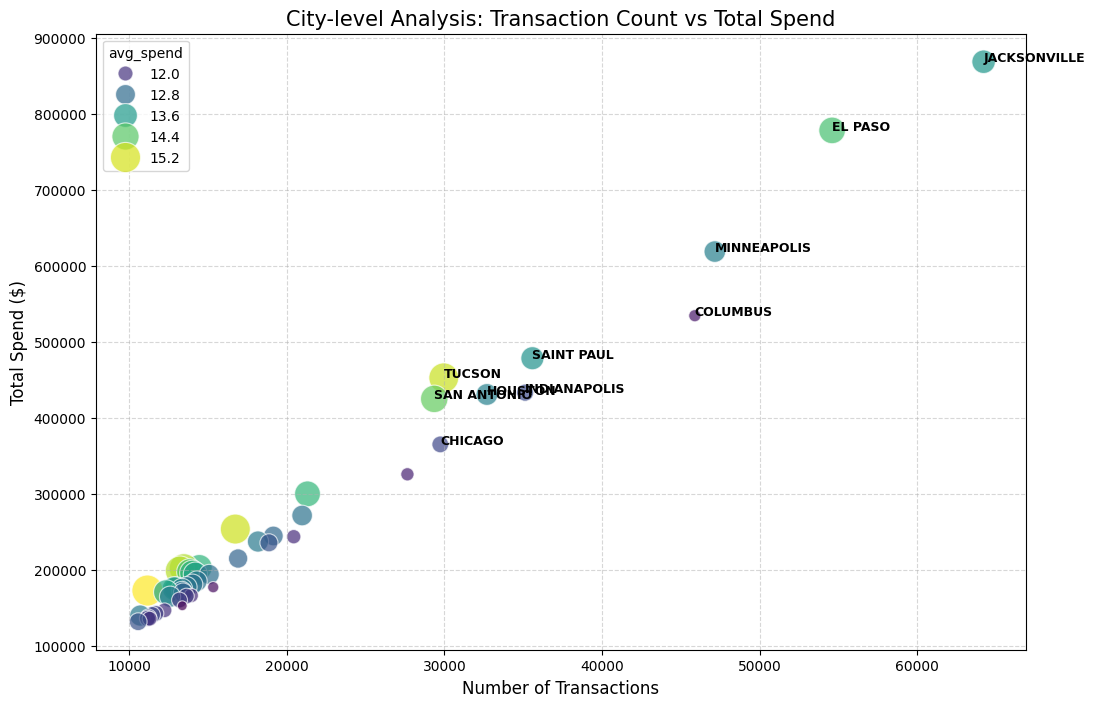

C:\Users\한민영\AppData\Local\Temp\ipykernel_24376\1073192232.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


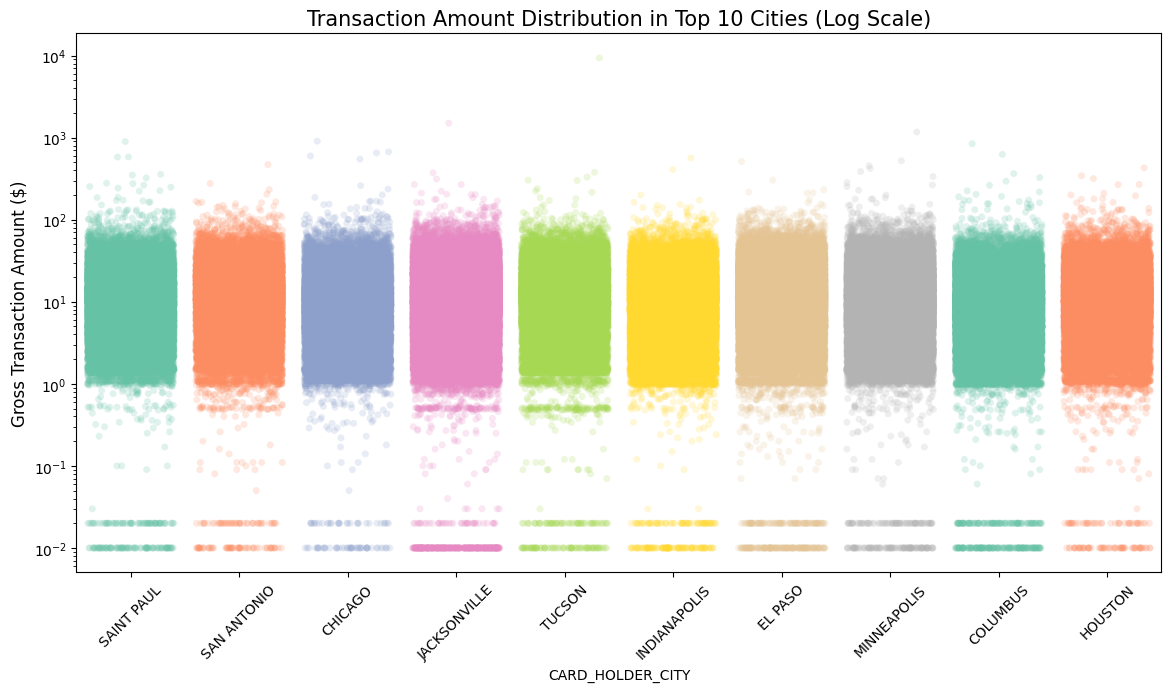

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 도시별 요약 통계량 계산
# 각 도시별로 [총 결제액, 평균 결제액, 결제 횟수]를 집계합니다.
city_stats = df.groupby('CARD_HOLDER_CITY').agg(
    total_spend=('GROSS_TRANSACTION_AMOUNT', 'sum'),
    avg_spend=('GROSS_TRANSACTION_AMOUNT', 'mean'),
    transaction_count=('TRANSACTION_ID', 'count')
).reset_index()

# 데이터가 너무 많으므로 총 결제액 기준 상위 50개 도시만 필터링
top_50_cities = city_stats.sort_values(by='total_spend', ascending=False).head(50)

# --- 시각화 1: 도시별 결제 빈도 vs 총 결제액 산점도 ---
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=top_50_cities, 
    x='transaction_count', 
    y='total_spend', 
    size='avg_spend', # 점의 크기는 평균 결제 건당 금액
    hue='avg_spend', 
    palette='viridis',
    sizes=(50, 500),
    alpha=0.7
)

# 상위 10개 도시에 이름 라벨링
for i in range(10):
    plt.text(
        top_50_cities.iloc[i]['transaction_count'], 
        top_50_cities.iloc[i]['total_spend'], 
        top_50_cities.iloc[i]['CARD_HOLDER_CITY'], 
        fontsize=9, weight='bold'
    )

plt.title('City-level Analysis: Transaction Count vs Total Spend', fontsize=15)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Total Spend ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- 시각화 2: 상위 10개 도시의 결제 금액대 분포 (Strip Plot) ---
top_10_city_names = top_50_cities['CARD_HOLDER_CITY'].head(10).tolist()
subset_df = df[df['CARD_HOLDER_CITY'].isin(top_10_city_names)]

plt.figure(figsize=(14, 7))
# 데이터 양이 많으므로 jitter(흩뿌림)와 투명도(alpha) 조절이 중요합니다.
sns.stripplot(
    data=subset_df, 
    x='CARD_HOLDER_CITY', 
    y='GROSS_TRANSACTION_AMOUNT', 
    alpha=0.2, 
    palette='Set2',
    jitter=0.4
)

# 결제 금액의 편차가 크므로 y축을 로그 스케일로 조정하면 분포를 더 잘 볼 수 있습니다.
plt.yscale('log') 
plt.title('Transaction Amount Distribution in Top 10 Cities (Log Scale)', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Gross Transaction Amount ($)', fontsize=12)
plt.show()

C:\Users\한민영\AppData\Local\Temp\ipykernel_24376\755356890.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


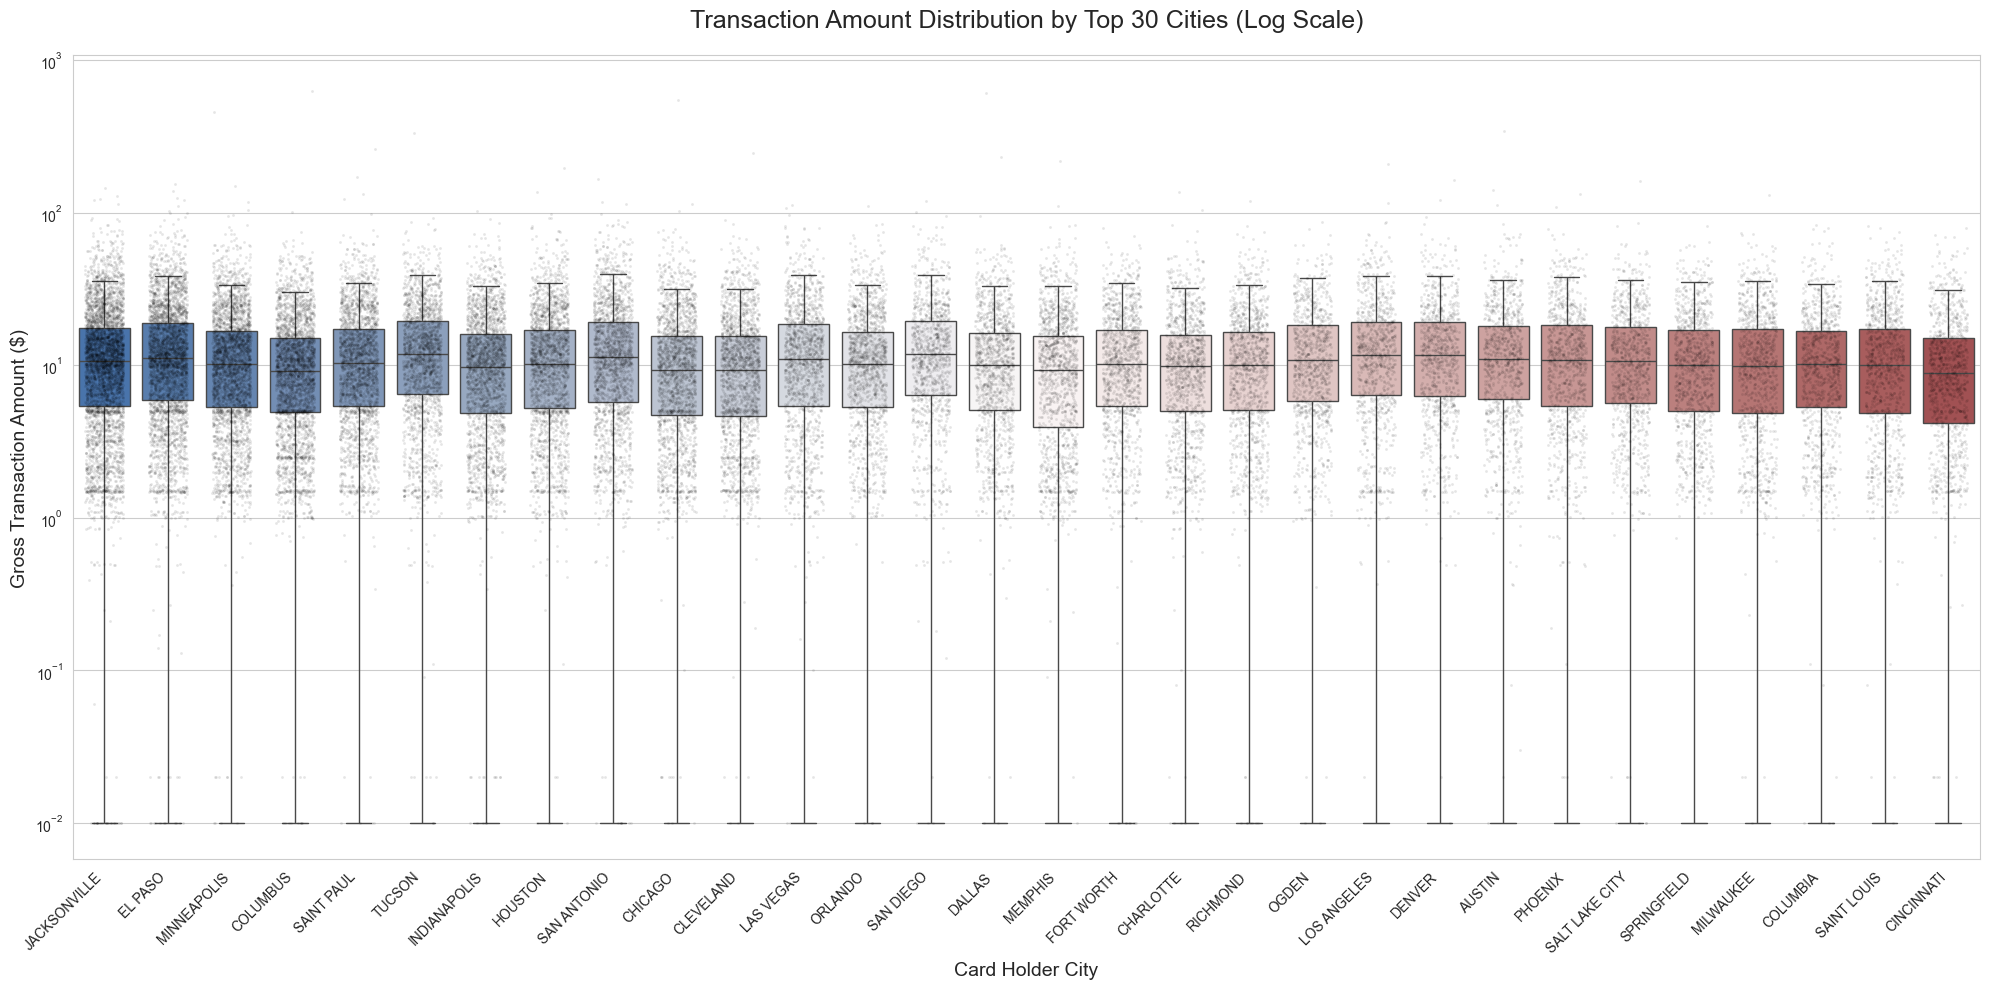

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 도시별 총 결제 금액 합계 계산 후 상위 30개 도시 추출
top_cities_list = df.groupby('CARD_HOLDER_CITY')['GROSS_TRANSACTION_AMOUNT'].sum().nlargest(30).index
subset_df = df[df['CARD_HOLDER_CITY'].isin(top_cities_list)]

# 2. 시각화 설정
plt.figure(figsize=(20, 10))

# 배경 그리드 설정
sns.set_style("whitegrid")

# (1) Boxplot: 중앙값, 사분위수 등 통계적 분포 확인
sns.boxplot(
    data=subset_df, 
    x='CARD_HOLDER_CITY', 
    y='GROSS_TRANSACTION_AMOUNT', 
    order=top_cities_list, 
    palette='vlag',
    showfliers=False # 이상치(Outlier)는 제외하고 박스만 깔끔하게 그림
)

# (2) Strip Plot: 실제 결제 데이터의 밀집도 확인
# 데이터가 너무 많으므로 5만 건 정도만 샘플링해서 찍는 것을 권장합니다 (속도 및 시각화 품질)
sample_df = subset_df.sample(n=min(50000, len(subset_df)))
sns.stripplot(
    data=sample_df, 
    x='CARD_HOLDER_CITY', 
    y='GROSS_TRANSACTION_AMOUNT', 
    order=top_cities_list,
    size=2, 
    color='black', 
    alpha=0.1, # 투명도를 낮게 주어 겹치는 정도(밀도) 확인
    jitter=0.3
)

# 3. 그래프 세부 조정
plt.yscale('log') # 금액 편차가 크므로 로그 스케일 적용 (필수!)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title('Transaction Amount Distribution by Top 30 Cities (Log Scale)', fontsize=18, pad=20)
plt.xlabel('Card Holder City', fontsize=14)
plt.ylabel('Gross Transaction Amount ($)', fontsize=14)

plt.tight_layout()
plt.show()

C:\Users\한민영\AppData\Local\Temp\ipykernel_24376\23874278.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


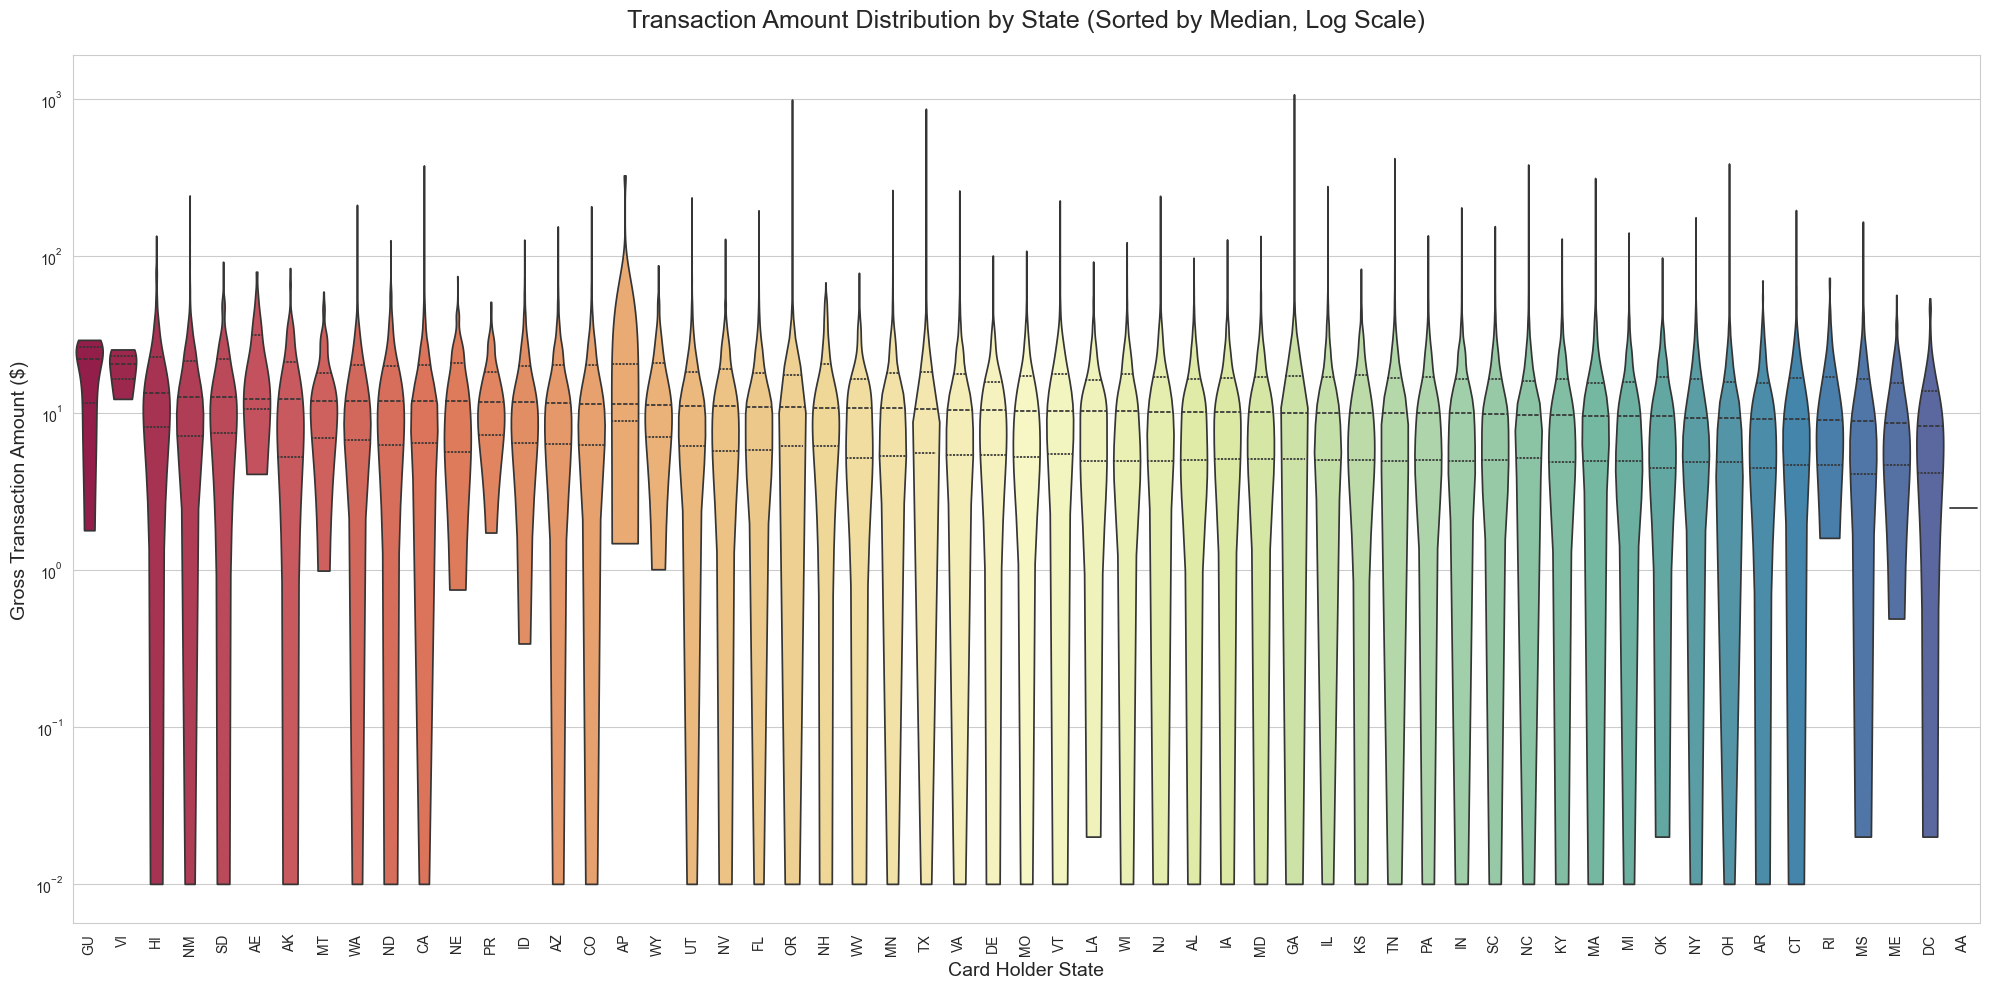

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화 데이터 준비 (너무 많으면 느리므로 10만 건 샘플링)
df_sample = df.sample(n=min(100000, len(df)), random_state=42)

# 2. 주별 평균 결제 금액 순으로 정렬 (보기 편하게 하기 위함)
state_order = df_sample.groupby('CARD_HOLDER_STATE')['GROSS_TRANSACTION_AMOUNT'].median().sort_values(ascending=False).index

# 3. 그래프 생성
plt.figure(figsize=(20, 10))
sns.set_style("whitegrid")

# (1) Violin Plot: 금액대의 밀도(Density)와 분포를 동시에 확인
# 결제 금액이 어디에 '가장 많이 몰려있는지'를 물고기 배 모양의 너비로 보여줍니다.
sns.violinplot(
    data=df_sample, 
    x='CARD_HOLDER_STATE', 
    y='GROSS_TRANSACTION_AMOUNT', 
    order=state_order,
    palette='Spectral',
    inner="quartile", # 중앙값과 사분위수 표시
    cut=0 # 데이터 범위 내에서만 그림
)

# 4. 세부 설정
plt.yscale('log') # $10~$1000 이상의 차이를 보기 위해 로그 스케일 필수
plt.xticks(rotation=90, fontsize=10) # 주의 이름이 많으므로 수직 회전
plt.title('Transaction Amount Distribution by State (Sorted by Median, Log Scale)', fontsize=18, pad=20)
plt.xlabel('Card Holder State', fontsize=14)
plt.ylabel('Gross Transaction Amount ($)', fontsize=14)

plt.tight_layout()
plt.show()

C:\Users\한민영\AppData\Local\Temp\ipykernel_24376\1535594200.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_user_df.head(20), x='State', y='User_Count', palette='magma')


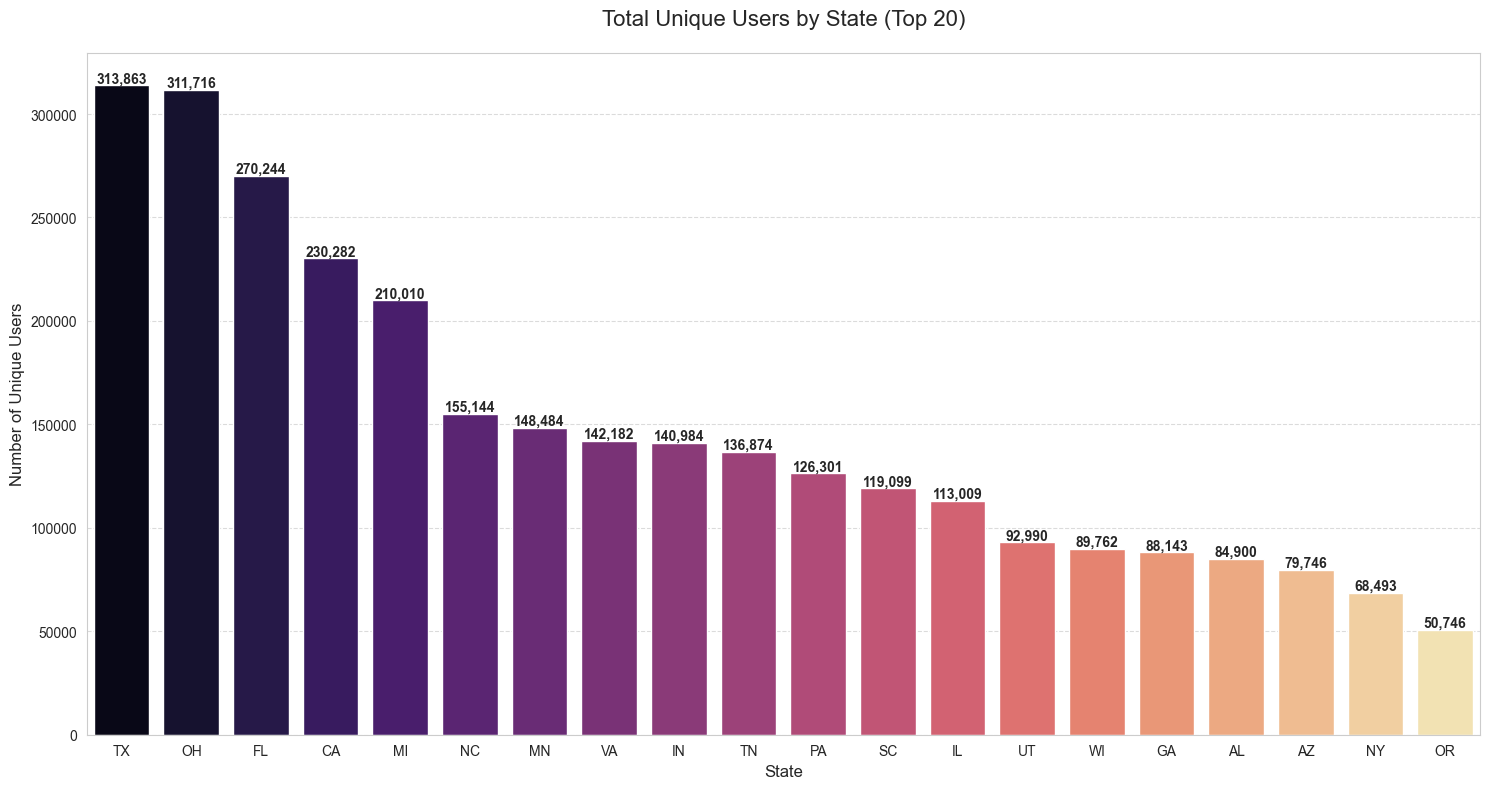

--- 주별 이용자 수 상위 10개 지역 ---
  State  User_Count
0    TX      313863
1    OH      311716
2    FL      270244
3    CA      230282
4    MI      210010
5    NC      155144
6    MN      148484
7    VA      142182
8    IN      140984
9    TN      136874


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 주별 유니크 이용자(ACCOUNT_ID) 수 집계
# nunique() 함수를 사용하여 중복된 ID를 제외한 실제 고객 수를 계산합니다.
state_user_counts = df.groupby('CARD_HOLDER_STATE')['ACCOUNT_ID'].nunique().sort_values(ascending=False)

# 2. 데이터프레임 형태로 변환 (보고용)
state_user_df = state_user_counts.reset_index()
state_user_df.columns = ['State', 'User_Count']

# 3. 시각화 (상위 20개 주)
plt.figure(figsize=(15, 8))
sns.barplot(data=state_user_df.head(20), x='State', y='User_Count', palette='magma')

# 그래프 위에 숫자 표시 (Data Labeling)
for i, val in enumerate(state_user_df.head(20)['User_Count']):
    plt.text(i, val, f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Total Unique Users by State (Top 20)', fontsize=16, pad=20)
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Unique Users', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 4. 결과 출력
print("--- 주별 이용자 수 상위 10개 지역 ---")
print(state_user_df.head(10))

--- ANOVA 분석 결과 ---
                                df        sum_sq       mean_sq          F  \
C(CARD_HOLDER_GENERATION)      4.0  6.646787e+04  16616.968571  99.091814   
Residual                   49995.0  8.383794e+06    167.692647        NaN   

                                 PR(>F)  
C(CARD_HOLDER_GENERATION)  3.674350e-84  
Residual                            NaN  

--- 사후 검정 (Tukey HSD) 결과 ---
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1     group2   meandiff p-adj   lower   upper  reject
-------------------------------------------------------------
Baby Boomer      Gen X   0.2951 0.5138 -0.2162  0.8065  False
Baby Boomer      Gen Z  -3.0305    0.0 -3.5907 -2.4703   True
Baby Boomer Millennial  -1.1346    0.0 -1.6163 -0.6529   True
Baby Boomer     Silent   0.7491 0.9373 -1.8805  3.3788  False
      Gen X      Gen Z  -3.3257    0.0 -3.8106 -2.8408   True
      Gen X Millennial  -1.4297    0.0 -1.8213 -1.0382   True
      Gen X     Silent    0.454 0.

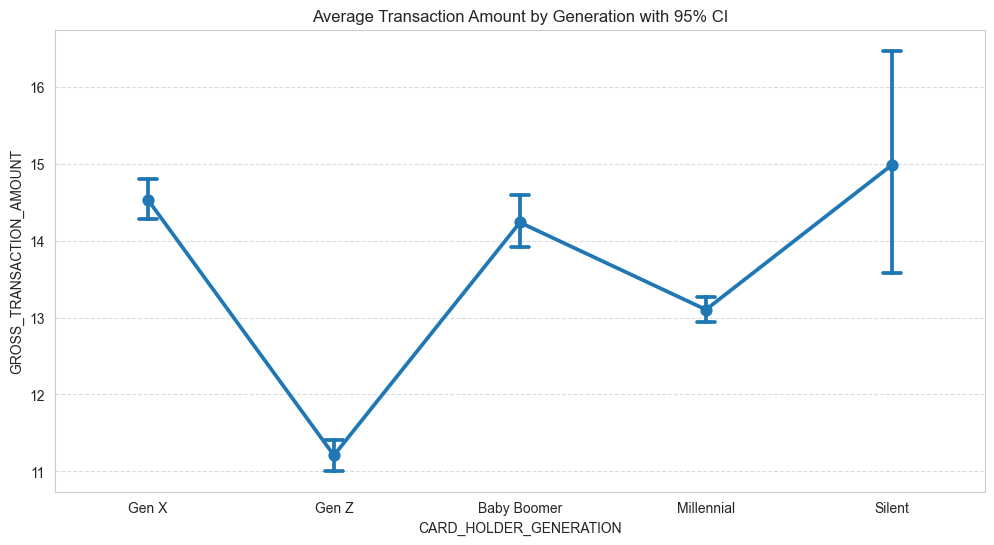

In [12]:
import pandas as pd
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. 데이터 준비 (결측치 제거 및 샘플링)
# 분석의 정확성을 위해 GENERATION과 AMOUNT가 있는 행만 사용합니다.
analysis_df = df.dropna(subset=['CARD_HOLDER_GENERATION', 'GROSS_TRANSACTION_AMOUNT'])

# 데이터가 너무 많으므로 통계적 유의성을 확보할 수 있는 수준(예: 5만 건)으로 샘플링합니다.
df_sample = analysis_df.sample(n=50000, random_state=42)

# 2. 일원 분산분석 (One-way ANOVA) 수행
# 모델 포뮬러: 금액 ~ 세대
model = ols('GROSS_TRANSACTION_AMOUNT ~ C(CARD_HOLDER_GENERATION)', data=df_sample).fit()
anova_results = anova_lm(model)

print("--- ANOVA 분석 결과 ---")
print(anova_results)

# 3. 사후 검정 (Post-hoc Test: Tukey HSD)
# ANOVA에서 유의미한 차이가 발견되었을 때, 구체적으로 '어느 세대 간'에 차이가 나는지 확인합니다.
print("\n--- 사후 검정 (Tukey HSD) 결과 ---")
posthoc = pairwise_tukeyhsd(df_sample['GROSS_TRANSACTION_AMOUNT'], 
                            df_sample['CARD_HOLDER_GENERATION'], 
                            alpha=0.05)
print(posthoc.summary())

# 4. 시각화: 세대별 평균 및 신뢰구간
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.pointplot(data=df_sample, x='CARD_HOLDER_GENERATION', y='GROSS_TRANSACTION_AMOUNT', 
              capsize=.1, errorbar='ci')
plt.title('Average Transaction Amount by Generation with 95% CI')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [13]:
null_pct = df['CARD_HOLDER_GENERATION'].isnull().mean() * 100
print(f"남은 세대 결측치 비중: {null_pct:.4f}%")

남은 세대 결측치 비중: 1.2100%


<Figure size 1500x800 with 0 Axes>

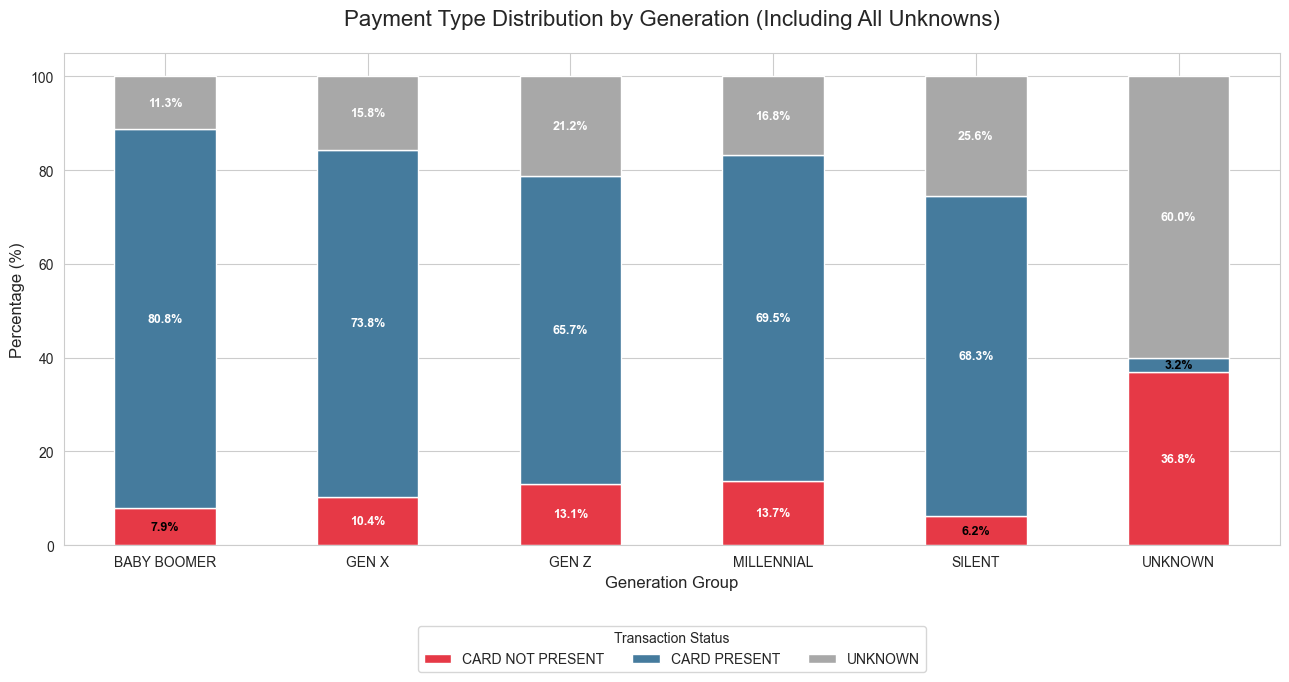

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 전처리 (모든 Unknown 값을 대문자로 통일)
df['CARD_HOLDER_GENERATION'] = df['CARD_HOLDER_GENERATION'].astype(str).str.upper()
df['CARD_PRESENT_INDICATOR'] = df['CARD_PRESENT_INDICATOR'].astype(str).str.upper()

# 2. 세대별, 모든 결제 방식별(UNKNOWN 포함) 집계
# 필터링 없이 모든 indicator 값을 사용합니다.
present_dist = df.groupby(['CARD_HOLDER_GENERATION', 'CARD_PRESENT_INDICATOR']).size().unstack(fill_value=0)

# 3. 가독성을 위해 컬럼 순서 재배치 (Online -> Offline -> Unknown 순서)
# 데이터에 실제로 존재하는 컬럼명으로 정확히 매칭해야 합니다.
cols = ['CARD NOT PRESENT', 'CARD PRESENT', 'UNKNOWN']
present_dist = present_dist[[c for c in cols if c in present_dist.columns]]

# 4. 수치형 변환 및 비율 계산
present_pct = present_dist.astype(float).div(present_dist.sum(axis=1), axis=0) * 100

# 5. 시각화
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# 색상 설정 (빨강: 온라인, 파랑: 오프라인, 회색: 알 수 없음)
colors = ['#E63946', '#457B9D', '#A8A8A8']
ax = present_pct.plot(kind='bar', stacked=True, color=colors[:len(present_dist.columns)], figsize=(13, 7))

# 수치 표시 로직
for n, x in enumerate([*present_pct.index.values]):
    for (proportion, y_loc) in zip(present_pct.loc[x], present_pct.loc[x].cumsum()):
        if proportion > 2: # 2% 이상인 경우만 표시
            plt.text(x=n,
                     y=(y_loc - proportion) + (proportion / 2),
                     s=f'{proportion:.1f}%', 
                     color="white" if proportion > 10 else "black", 
                     fontsize=9, fontweight="bold", ha="center", va="center")

# 6. 세부 설정
plt.title('Payment Type Distribution by Generation (Including All Unknowns)', fontsize=16, pad=20)
plt.xlabel('Generation Group', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Transaction Status', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

<Figure size 1500x800 with 0 Axes>

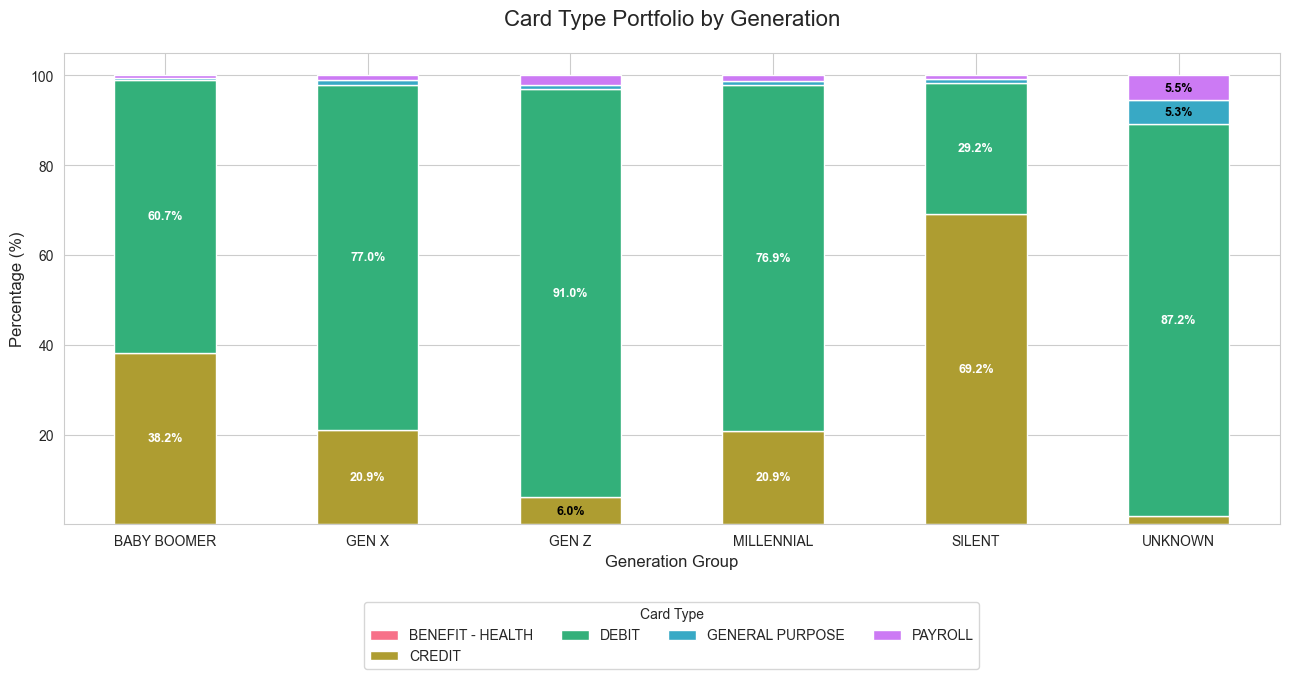

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 전처리 (세대 정보 대문자 통일 및 결측치 처리)
df['CARD_HOLDER_GENERATION'] = df['CARD_HOLDER_GENERATION'].astype(str).str.upper()
df['CARD_TYPE'] = df['CARD_TYPE'].astype(str).str.upper()

# 2. 세대별, 카드 종류별 결제 건수 집계
card_dist = df.groupby(['CARD_HOLDER_GENERATION', 'CARD_TYPE']).size().unstack(fill_value=0)

# 3. 수치형 데이터 변환 및 100% 비율 계산
# (전체 477만 건의 분포를 비율로 환산하여 세대 간 '선호도'를 비교합니다)
card_pct = card_dist.astype(float).div(card_dist.sum(axis=1), axis=0) * 100

# 4. 시각화 (Stacked Bar Chart)
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# 컬러 팔레트 설정 (카드 종류 개수에 따라 자동 조절)
colors = sns.color_palette("husl", len(card_pct.columns))
ax = card_pct.plot(kind='bar', stacked=True, color=colors, figsize=(13, 7))

# 수치 표시 로직 (비중이 3% 이상인 경우만 중앙에 표시)
for n, x in enumerate([*card_pct.index.values]):
    for (proportion, y_loc) in zip(card_pct.loc[x], card_pct.loc[x].cumsum()):
        if proportion > 3:
            plt.text(x=n,
                     y=(y_loc - proportion) + (proportion / 2),
                     s=f'{proportion:.1f}%', 
                     color="white" if proportion > 15 else "black", 
                     fontsize=9, fontweight="bold", ha="center", va="center")

# 5. 그래프 세부 설정
plt.title('Card Type Portfolio by Generation', fontsize=16, pad=20)
plt.xlabel('Generation Group', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Card Type', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4777635 entries, 0 to 4777634
Data columns (total 27 columns):
 #   Column                                     Dtype  
---  ------                                     -----  
 0   ACCOUNT_ID                                 str    
 1   CARD_ID                                    str    
 2   TRANSACTION_ID                             str    
 3   GROSS_TRANSACTION_AMOUNT                   float64
 4   TRANSACTION_DATE                           str    
 5   TRANSACTION_TYPE                           str    
 6   TRANSACTION_STATE                          str    
 7   TRANSACTION_CITY                           str    
 8   MERCHANT_STATE                             str    
 9   MERCHANT_CITY                              str    
 10  MERCHANT_CATEGORY_LEVEL_1                  str    
 11  MERCHANT_CATEGORY_LEVEL_2                  str    
 12  MERCHANT_CATEGORY_LEVEL_3                  str    
 13  TRANSACTION_DESCRIPTION                    str    
 1

In [25]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def get_cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    if n == 0: return 0
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 전체 열 목록 (타겟 제외)
all_columns = [col for col in df.columns if col != 'CARD_HOLDER_STATE']
v_scores = []

# 데이터가 크므로 10만 건 샘플로 전수 조사
df_sample = df.dropna(subset=['CARD_HOLDER_STATE']).sample(100000, random_state=42)

for col in all_columns:
    # 1. 결측치가 너무 많은 열(50% 이상)은 학습 도구로 부적합하므로 제외
    if df[col].isnull().mean() > 0.5:
        continue
    
    # 2. 범주형 변수 위주로 Cramer's V 계산
    try:
        score = get_cramers_v(df_sample['CARD_HOLDER_STATE'], df_sample[col])
        v_scores.append((col, score))
    except:
        continue

# 연관성 높은 순으로 정렬
v_scores.sort(key=lambda x: x[1], reverse=True)
print("--- CARD_HOLDER_STATE와 연관성이 높은 상위 변수 ---")
for col, score in v_scores[:7]:
    print(f"Variable: {col:30} | Cramer's V: {score:.4f}")

C:\Users\한민영\AppData\Local\Temp\ipykernel_24376\3433289525.py:15: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))


--- CARD_HOLDER_STATE와 연관성이 높은 상위 변수 ---
Variable: TRANSACTION_ID                 | Cramer's V: nan
Variable: TRANSACTION_STATE              | Cramer's V: 0.8460
Variable: CARD_HOLDER_CITY               | Cramer's V: 0.8381
Variable: MERCHANT_STATE                 | Cramer's V: 0.7727
Variable: TRANSACTION_CITY               | Cramer's V: 0.7391
Variable: MERCHANT_CITY                  | Cramer's V: 0.6800
Variable: TRANSACTION_DESCRIPTION        | Cramer's V: 0.4296


In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# 최종 피처 선정: 결측치가 적고 연관성이 높은 변수들
final_features = ['TRANSACTION_STATE', 'MERCHANT_STATE', 'TRANSACTION_CITY', 'CARD_TYPE', 'CARD_HOLDER_GENERATION']

# 1. 데이터 준비 (피처들도 결측치가 있을 수 있으므로 'UNKNOWN'으로 채우기)
df_model = df.copy()
for col in final_features:
    df_model[col] = df_model[col].fillna('UNKNOWN').astype(str)

# 2. 라벨 인코딩 (모든 범주형 변수를 숫자로 변환)
le_dict = {}
for col in final_features + ['CARD_HOLDER_STATE']:
    le = LabelEncoder()
    # 학습은 STATE가 있는 데이터로만 진행
    mask = df_model['CARD_HOLDER_STATE'].notna()
    df_model.loc[mask, col] = le.fit_transform(df_model.loc[mask, col])
    le_dict[col] = le

# 3. Train / Test 분리
train_data = df_model[df_model['CARD_HOLDER_STATE'].notna()]
X = train_data[final_features]
y = train_data['CARD_HOLDER_STATE'].astype(str) # 타겟은 문자열로 유지 가능

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 의사결정 나무 학습 (정확도를 높이기 위해 깊이를 조절)
dt_clf = DecisionTreeClassifier(max_depth=15, min_samples_split=100, random_state=42)
dt_clf.fit(X_train, y_train)

# 5. 정확도 확인
y_pred = dt_clf.predict(X_test)
print(f"의사결정 나무 모델 정확도: {accuracy_score(y_test, y_pred):.4f}")

TypeError: Invalid value for dtype 'str'. Value should be a string or missing value (or array of those).

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. 데이터 준비 및 타입 유연화
# 피처 선정: Cramer's V 결과 기반
final_features = ['TRANSACTION_STATE', 'MERCHANT_STATE', 'TRANSACTION_CITY', 'CARD_TYPE', 'CARD_HOLDER_GENERATION']

# 원본 보존을 위해 복사본 생성 및 타입을 object로 변경 (정수 입력 허용을 위함)
df_model = df.copy()
for col in final_features + ['CARD_HOLDER_STATE']:
    df_model[col] = df_model[col].fillna('UNKNOWN').astype(object)

# 2. 라벨 인코딩 (데이터 타입 충돌 회피)
le_dict = {}
mask = df['CARD_HOLDER_STATE'].notna() # 원본 기준 결측치 없는 행만 학습 대상

for col in final_features + ['CARD_HOLDER_STATE']:
    le = LabelEncoder()
    # 학습 대상인 데이터만 문자열로 변환하여 학습
    target_data = df_model.loc[mask, col].astype(str)
    encoded_values = le.fit_transform(target_data)
    
    # 해당 위치에 인코딩된 정수값 삽입
    df_model.loc[mask, col] = encoded_values
    le_dict[col] = le

# 3. Train / Test 분리 (학습 데이터만 추출)
train_data = df_model[mask].copy()

# 입력 데이터(X)는 정수형으로, 타겟(y)도 정수형으로 확실히 변환
X = train_data[final_features].astype(int)
y = train_data['CARD_HOLDER_STATE'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 의사결정 나무 학습
# max_depth를 15 정도로 주어 규칙을 너무 복잡하지 않게 만듭니다.
dt_clf = DecisionTreeClassifier(max_depth=15, min_samples_split=100, random_state=42)
dt_clf.fit(X_train, y_train)

# 5. 정확도 확인
y_pred = dt_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"의사결정 나무 모델 정확도: {acc:.4f}")

의사결정 나무 모델 정확도: 0.8668


In [29]:
# 1. 복구가 필요한 결측치 행 추출
null_mask = df['CARD_HOLDER_STATE'].isna()

# 2. [핵심] 결측치 구간의 피처들도 학습 때 사용한 le_dict를 이용해 숫자로 변환
X_null_raw = df_model.loc[null_mask, final_features].copy()
X_null_encoded = pd.DataFrame(index=X_null_raw.index)

for col in final_features:
    le = le_dict[col]
    # 학습 때 보지 못한 새로운 값이 있을 수 있으므로 처리 (안전장치)
    # 알려진 값은 인코딩하고, 처음 보는 값은 'UNKNOWN'의 인덱스로 대체
    X_null_encoded[col] = X_null_raw[col].map(lambda s: le.transform([str(s)])[0] if str(s) in le.classes_ else le.transform(['UNKNOWN'])[0])

# 3. 모델을 이용한 예측 실행 (이제 모두 숫자이므로 astype(int)가 잘 작동합니다)
X_null_input = X_null_encoded.astype(int)
predicted_states_encoded = dt_clf.predict(X_null_input)

# 4. 인코딩된 숫자를 다시 원래의 '주(State)' 이름으로 역변환
target_le = le_dict['CARD_HOLDER_STATE']
predicted_states = target_le.inverse_transform(predicted_states_encoded)

# 5. 원본 데이터프레임(df)에 반영
df.loc[null_mask, 'CARD_HOLDER_STATE'] = predicted_states

print(f"✅ 성공적으로 {len(predicted_states):,}건의 거주지 결측치를 복구했습니다!")
print(f"현재 CARD_HOLDER_STATE 남은 결측치 수: {df['CARD_HOLDER_STATE'].isna().sum()}")

✅ 성공적으로 15,934건의 거주지 결측치를 복구했습니다!
현재 CARD_HOLDER_STATE 남은 결측치 수: 0


In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# 1. 피처 선정: 도시를 예측하기 위해 가장 중요한 '주(State)' 정보와 '가맹점 도시'를 포함
# TRANSACTION_CITY와 MERCHANT_CITY가 Cramer's V 결과에서 매우 높게 나왔던 점을 활용합니다.
city_features = ['CARD_HOLDER_STATE', 'TRANSACTION_CITY', 'MERCHANT_CITY', 'CARD_TYPE']

# 2. 데이터 준비 및 타입 유연화
df_city_model = df.copy()
for col in city_features + ['CARD_HOLDER_CITY']:
    df_city_model[col] = df_city_model[col].fillna('UNKNOWN').astype(object)

# 3. 라벨 인코딩 (학습용)
le_city_dict = {}
city_mask = df['CARD_HOLDER_CITY'].notna() # 원본 기준 City 결측치 없는 행만 학습

for col in city_features + ['CARD_HOLDER_CITY']:
    le = LabelEncoder()
    target_data = df_city_model.loc[city_mask, col].astype(str)
    encoded_values = le.fit_transform(target_data)
    df_city_model.loc[city_mask, col] = encoded_values
    le_city_dict[col] = le

# 4. Train / Test 분리
train_city_data = df_city_model[city_mask].copy()
X_city = train_city_data[city_features].astype(int)
y_city = train_city_data['CARD_HOLDER_CITY'].astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_city, y_city, test_size=0.2, random_state=42)

# 5. 모델 학습
# 도시 종류가 많으므로 max_depth를 조금 더 깊게(20~25) 설정하는 것이 유리할 수 있습니다.
dt_city_clf = DecisionTreeClassifier(max_depth=20, min_samples_split=50, random_state=42)
dt_city_clf.fit(X_train_c, y_train_c)

# 6. 정확도 확인
y_pred_c = dt_city_clf.predict(X_test_c)
print(f"도시(City) 예측 모델 정확도: {accuracy_score(y_test_c, y_pred_c):.4f}")

MemoryError: Unable to allocate 111. GiB for an array with shape (952341, 1, 15613) and data type float64

In [32]:
import numpy as np
import pandas as pd

# 1. 배치 예측 함수 정의 (메모리 에러 방지용)
def batch_predict(model, X_data, batch_size=5000):
    predictions = []
    for i in range(0, len(X_data), batch_size):
        X_batch = X_data.iloc[i:i+batch_size]
        pred_batch = model.predict(X_batch)
        predictions.append(pred_batch)
    return np.concatenate(predictions)

# 2. 복구가 필요한 결측치 행 데이터 준비 (X_city_null_encoded 생성)
print("1단계: 결측치 데이터 전처리 중...")
city_null_mask = df['CARD_HOLDER_CITY'].isna()
X_city_null_raw = df_city_model.loc[city_null_mask, city_features].copy()
X_city_null_encoded = pd.DataFrame(index=X_city_null_raw.index)

# 학습 때 사용한 le_city_dict를 활용해 인코딩
for col in city_features:
    le = le_city_dict[col]
    X_city_null_encoded[col] = X_city_null_raw[col].map(
        lambda s: le.transform([str(s)])[0] if str(s) in le.classes_ else le.transform(['UNKNOWN'])[0]
    )

# 3. 모델을 이용한 분할 예측 실행
print("2단계: 결측치 데이터 분할 예측 시작 (Batch 처리)...")
predicted_cities_encoded = batch_predict(dt_city_clf, X_city_null_encoded.astype(int))

# 4. 역변환 및 원본 데이터프레임 반영
print("3단계: 원본 데이터 복구 및 반영 중...")
target_city_le = le_city_dict['CARD_HOLDER_CITY']
predicted_cities = target_city_le.inverse_transform(predicted_cities_encoded)
df.loc[city_null_mask, 'CARD_HOLDER_CITY'] = predicted_cities

print(f"✨ 축하합니다! {len(predicted_cities):,}건의 도시 결측치가 완벽하게 복구되었습니다.")
print(f"현재 데이터프레임 내 남은 City 결측치: {df['CARD_HOLDER_CITY'].isna().sum()}건")

1단계: 결측치 데이터 전처리 중...
2단계: 결측치 데이터 분할 예측 시작 (Batch 처리)...
3단계: 원본 데이터 복구 및 반영 중...
✨ 축하합니다! 15,934건의 도시 결측치가 완벽하게 복구되었습니다.
현재 데이터프레임 내 남은 City 결측치: 0건


In [33]:
from sklearn.metrics import accuracy_score

# 1. 거주지(STATE) 모델 정확도 재확인
y_pred_state = dt_clf.predict(X_test)
print(f"✅ 거주지(STATE) 예측 정확도: {accuracy_score(y_test, y_pred_state):.4f}")

# 2. 도시(CITY) 모델 정확도 재확인 (배치 예측 함수 사용)
y_pred_city = batch_predict(dt_city_clf, X_test_c)
print(f"✅ 거주 도시(CITY) 예측 정확도: {accuracy_score(y_test_c, y_pred_city):.4f}")

✅ 거주지(STATE) 예측 정확도: 0.8668
✅ 거주 도시(CITY) 예측 정확도: 0.5053
